In [33]:
import argparse
import os
import time
import json
import tempfile

import dotenv
from astropy import units as u
from astropy.time import Time
from gcn_kafka import Consumer

from nutela.parse import parse_gcn_notice
from nutela.winter import schedule_winter, select_alerts_winter, get_winter_queue
# from nutela.winter.schedule import 
from planobs.api import Queue
from nutela.ztf import get_ztf_queue, schedule_ztf, select_alerts_ztf, BASE_CONSTRAINTS_KWARGS, LOOSE_CONSTRAINTS_KWARGS
from nutela.ztf.submit import submit_ztf
from nutela.ztf.utils import get_planner
from planobs.models import ObservingConstraints

In [2]:
dotenv.load_dotenv()

True

In [30]:
send_to_ztf = True
send_to_winter = True

In [4]:
get_ztf_queue()

,queue_name,validity_window_mjd,is_TOO,n_entries,field_id,filter_id,exposure_time,max_airmass
0,ToO_IC_142709_10606089_rev0_0,"[61202.25404440365, 61202.33876662587]",True,209,1728,1,300.0,2.5
1,ToO_IC_142709_10606089_rev0_1,"[61202.25404440365, 61202.33876662587]",True,210,1729,1,300.0,2.5
2,ToO_IC_142709_10606089_rev0_2,"[61202.349183292536, 61202.43390551476]",True,209,1728,2,300.0,2.5
3,ToO_IC_142709_10606089_rev0_3,"[61202.349183292536, 61202.43390551476]",True,210,1729,2,300.0,2.5


In [5]:
get_winter_queue()

,prog_name,attempted_frac,too_schedule_name,target_names,n_entries,total_time_hours,window_start,window_end,archived


# Load latest neutrino

In [6]:
client_id, client_secret = os.getenv("GCN_ID"), os.getenv("GCN_SECRET")

if client_id is None or client_secret is None:
    raise ValueError("Missing GCN_ID or GCN_SECRET in .env file")

config = {"auto.offset.reset": "earliest"}

consumer = Consumer(
    client_id=client_id, client_secret=client_secret, config=config
)

# # Subscribe to topics and receive alerts
consumer.subscribe(
    [
        "gcn.classic.text.ICECUBE_ASTROTRACK_BRONZE",
        "gcn.classic.text.ICECUBE_ASTROTRACK_GOLD",
    ]
)

In [7]:
messages = consumer.consume(timeout=1)

In [8]:
# See what you got
for i, msg in enumerate(messages):
    print(i, msg.topic(), msg.timestamp(), len(msg.value()), 'bytes')

0 gcn.classic.text.ICECUBE_ASTROTRACK_GOLD (1, 1781126845111) 1365 bytes


In [9]:
msg = messages[-1]

In [10]:
nu = parse_gcn_notice(msg)
nu_time = nu.event_time
nu

AstrotrackNotice(title='GCN/AMON NOTICE', notice_date='Wed 10 Jun 26 21:27:25 UT', notice_type='ICECUBE Astrotrack Gold', stream='24', run_num='142709', event_num='10606089', src_ra=309.2538, src_dec=37.0776, src_error=1.4386666666666665, src_error50=0.5603333333333332, discovery_date='21201 TJD;   161 DOY;   26/06/10 (yy/mm/dd)', discovery_time='72161 SOD {20:02:41.03} UT', energy=887.77, signalness=0.92151, far=0.1495, sun_dist=103.36, sun_postn=79.14, moon_dist=65.82, moon_postn=17.97, gal_coords='77.27, -2.33 [deg] galactic lon,lat of the event', ecl_coords='327.07, 53.02 [deg] ecliptic lon,lat of the event', comments='The position error is statistical only, there is no systematic added.', revision=0)

In [11]:
message_str = (
    f"Found neutrino at time {nu_time.isot}, of type {nu.notice_type}, "
    f"and energy {nu.energy:.0f} TeV. "
    f"Revision is {nu.revision}. \n"
    f"The signalness is {100.*nu.signalness:.0f}%, with a FAR of {nu.far:.2f} per year. \n"
    f"The sun distance is {nu.sun_dist:.0f} deg, "
    f"and the moon distance is {nu.moon_dist:.0f} deg. \n"
    f"The best fit coordinates are RA: {nu.src_ra:.2f}, Dec: {nu.src_dec:.2f}, "
    f"with uncertainty radius of {nu.src_error:.2f} degrees."
)
print(message_str)

Found neutrino at time 2026-06-10T20:02:41.030, of type ICECUBE Astrotrack Gold, and energy 888 TeV. Revision is 0. 
The signalness is 92%, with a FAR of 0.15 per year. 
The sun distance is 103 deg, and the moon distance is 66 deg. 
The best fit coordinates are RA: 309.25, Dec: 37.08, with uncertainty radius of 1.44 degrees.


# Schedule ZTF

In [12]:
valid_ztf = select_alerts_ztf(nu=nu)
valid_ztf

False

In [13]:
with tempfile.TemporaryDirectory() as tmpdirname:
    plan = get_planner(nu, temp_dir=tmpdirname)
    
    all_fields = plan.request_ztf_fields()

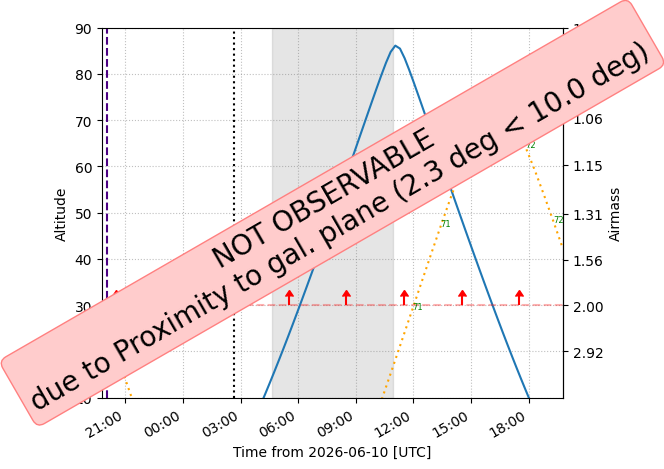

In [14]:
plan.plot_target()

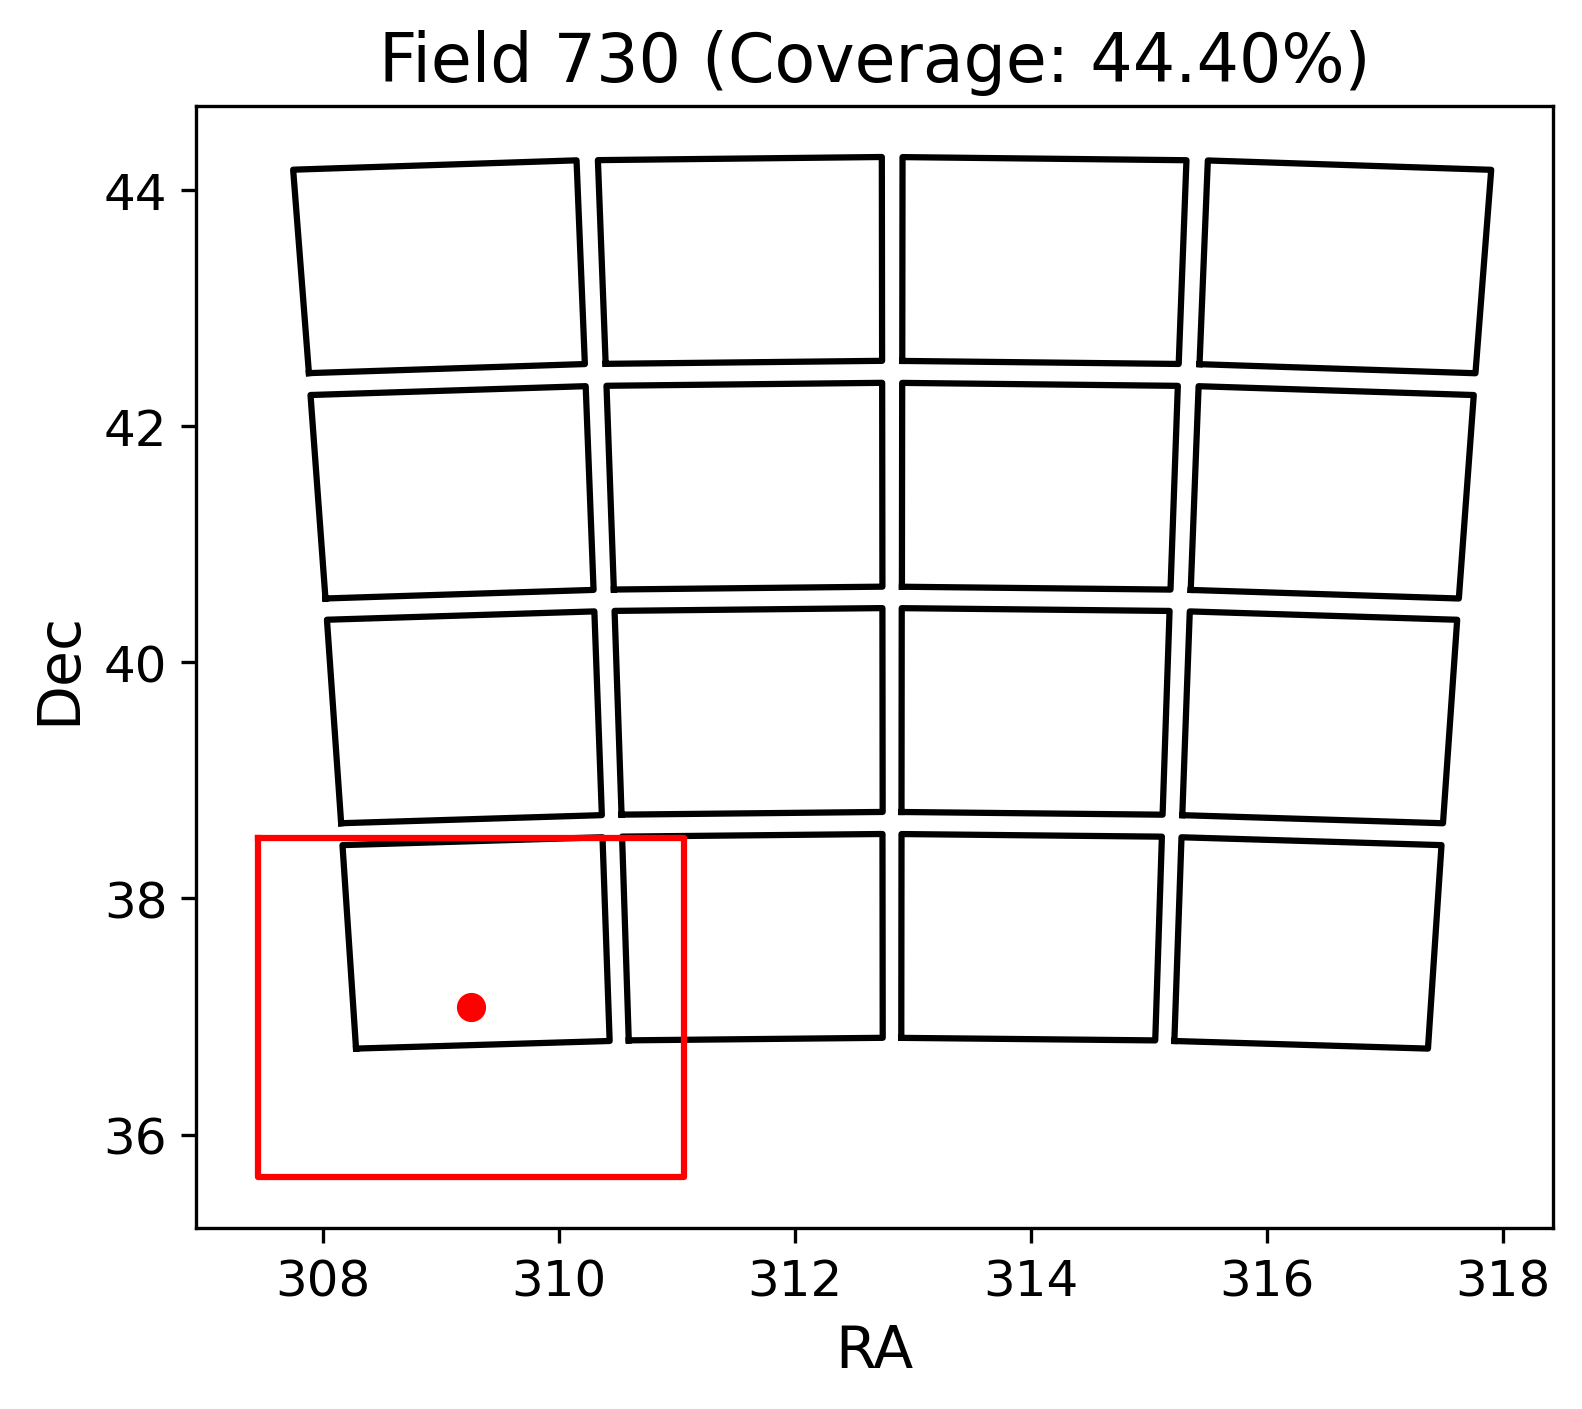

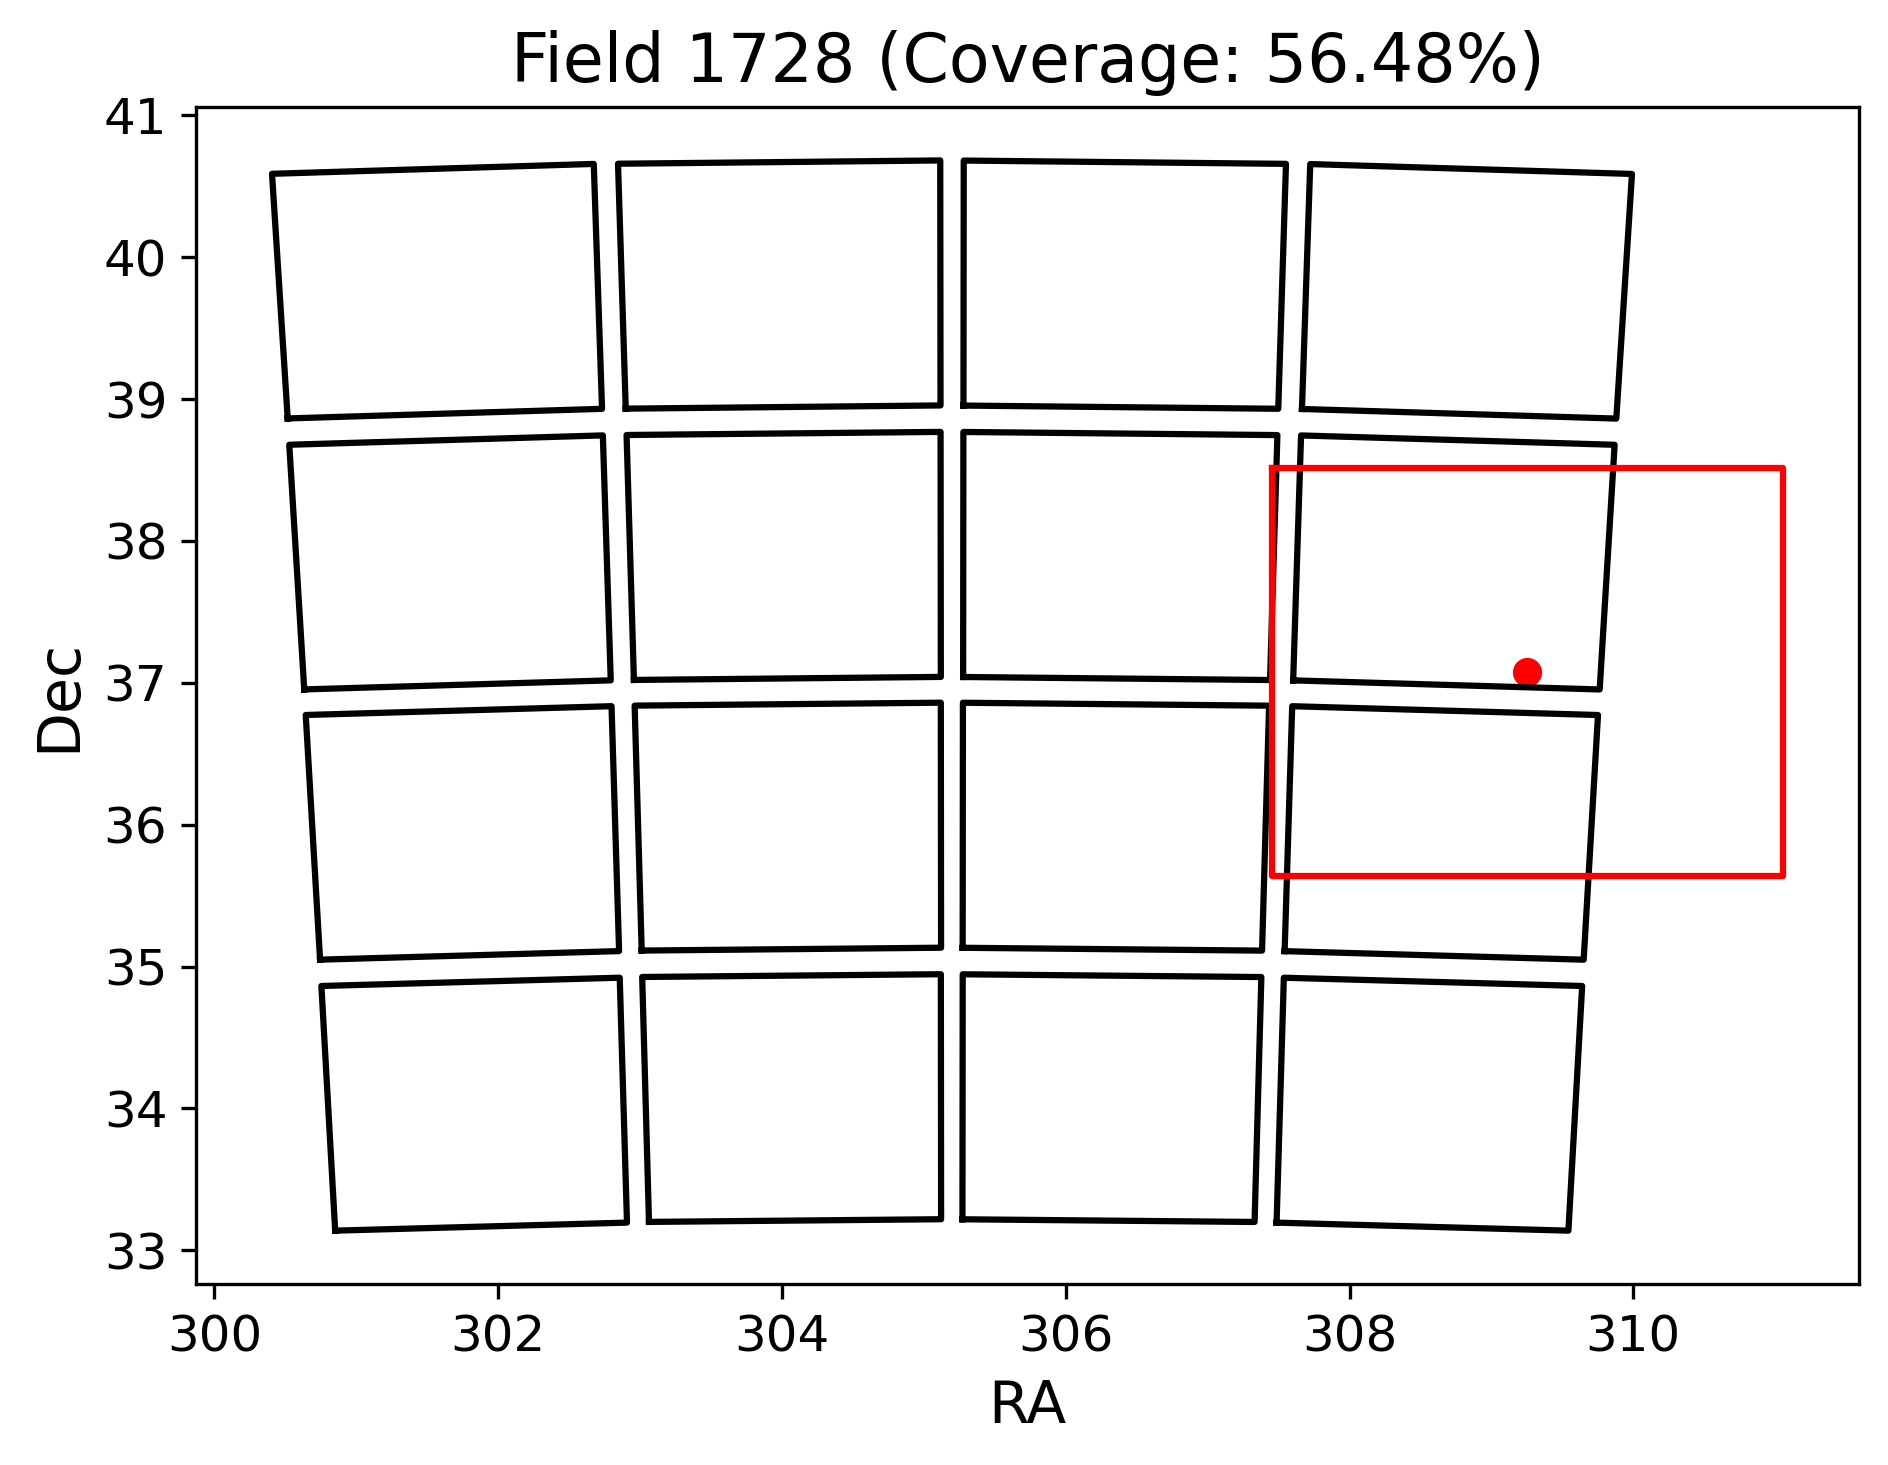

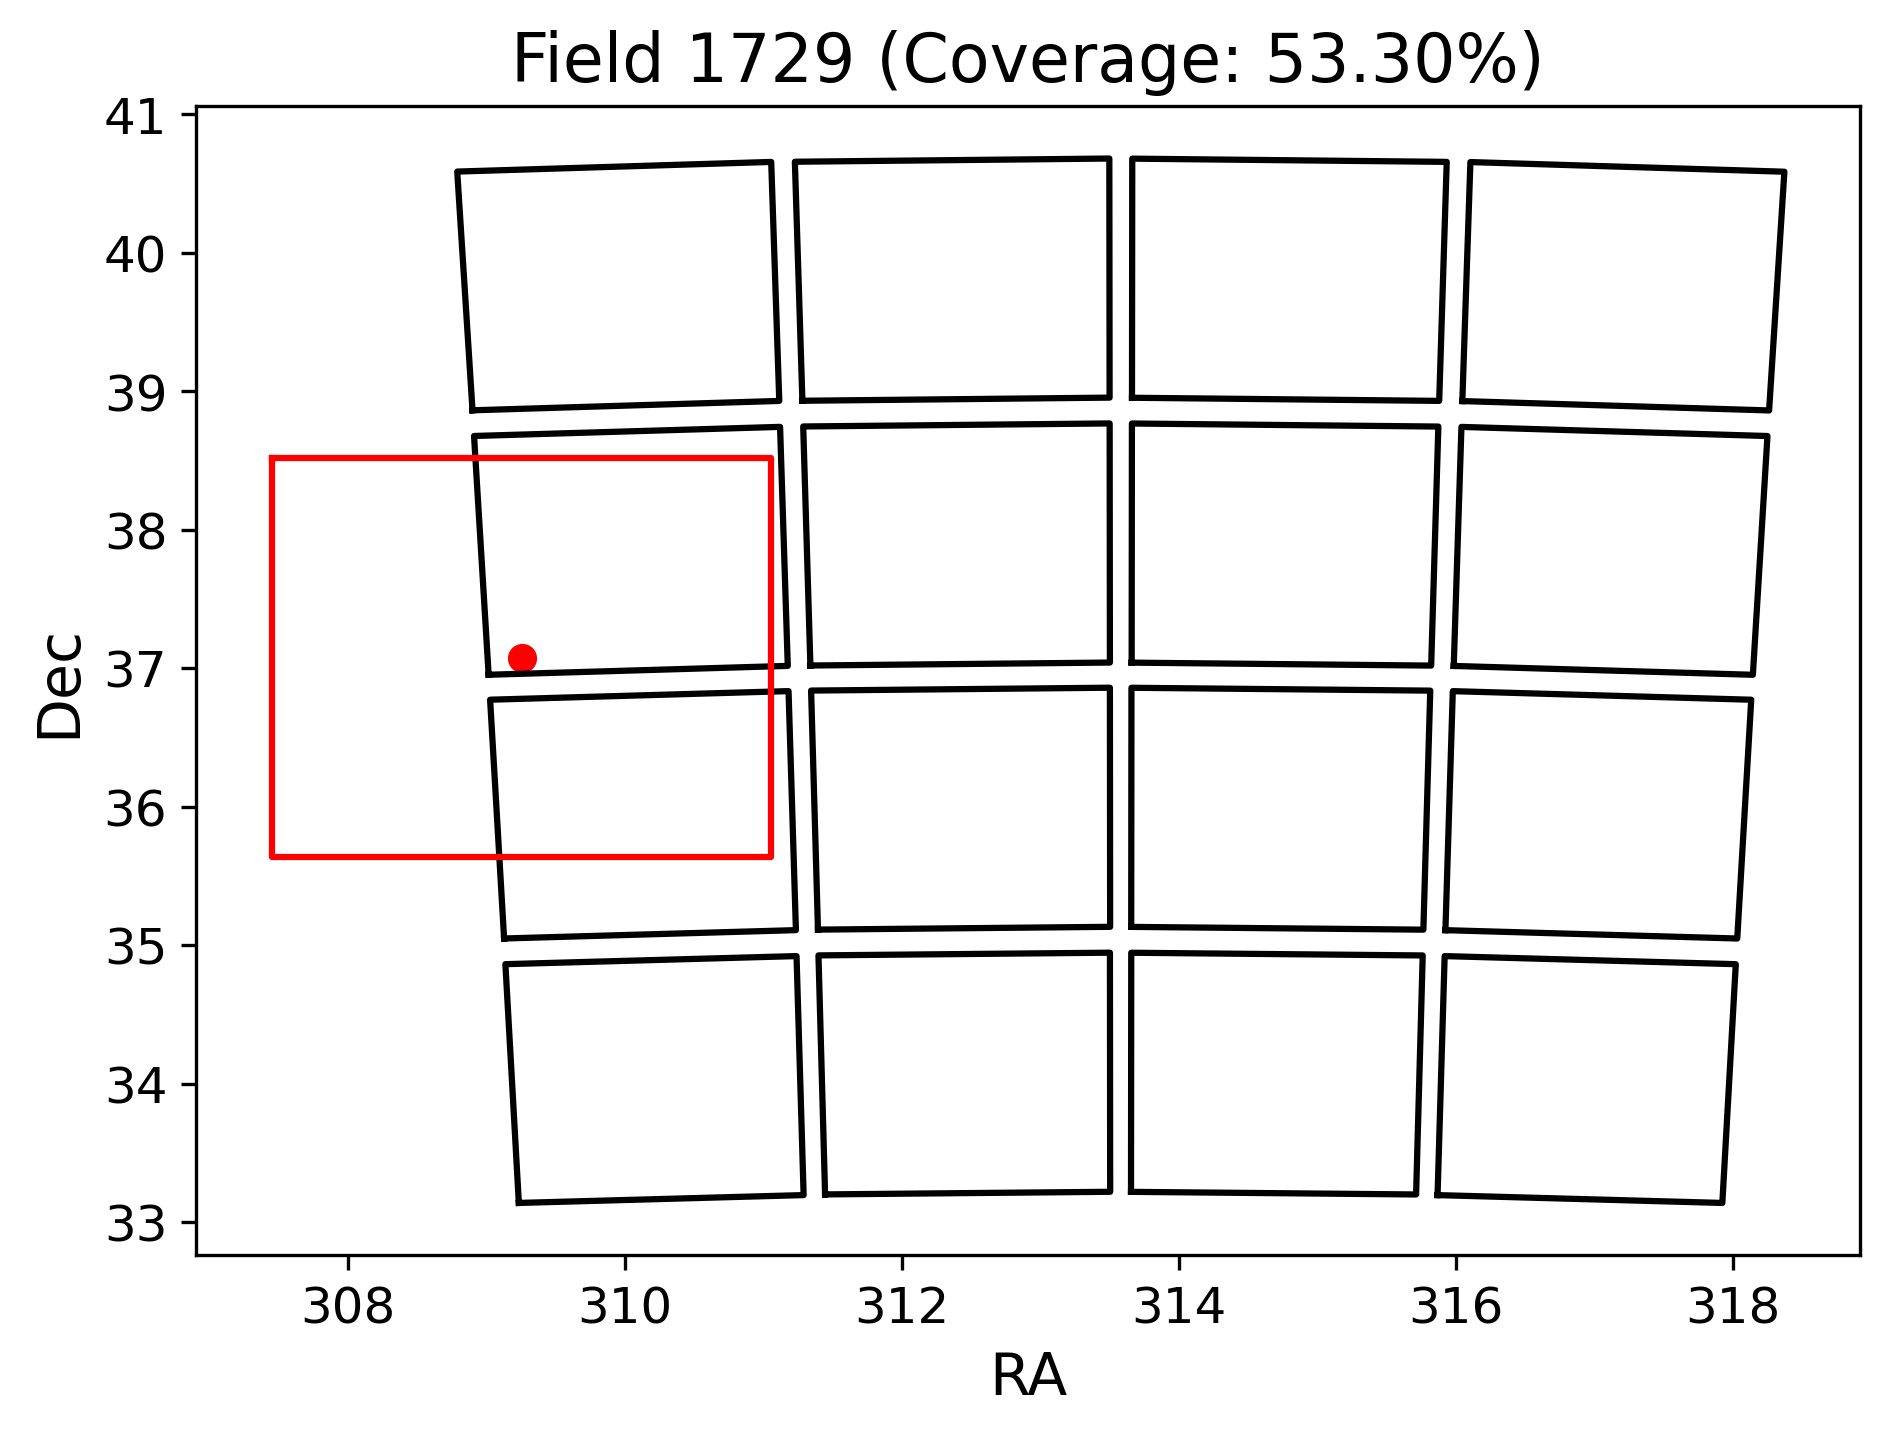

In [15]:
for field in all_fields:
    plan.plot_field(field)

In [16]:
type(plan.recommended_field)

int

In [17]:
overwrite_fields = None

overwrite_fields = [1728, 1729] # Uncomment to change

fields_to_use = overwrite_fields or [fields_to_use.recommended_field]
print(f"Using field(s) {fields_to_use}")

Using field(s) [1728, 1729]


In [18]:
# Rev 0
constraints = ObservingConstraints(
    bands=["g", "r"], exposure_time=300.0, **BASE_CONSTRAINTS_KWARGS, 
    min_galactic_latitude=0.0 # Maybe not needed always
)

schedule = plan.generate_schedule(constraints=constraints)
schedule

Schedule(rejection_reason=None, observations=[Observation(filter_name='g', exposure_time=300.0, start_time=<Time object: scale='utc' format='datetime' value=2026-06-11 06:06:26.447541>, end_time=<Time object: scale='utc' format='datetime' value=2026-06-11 08:08:26.447541>), Observation(filter_name='r', exposure_time=300.0, start_time=<Time object: scale='utc' format='datetime' value=2026-06-11 08:23:26.447541>, end_time=<Time object: scale='utc' format='datetime' value=2026-06-11 10:25:26.447541>)], sunset=<Time object: scale='utc' format='jd' value=2461202.6939537497>, sunrise=<Time object: scale='utc' format='jd' value=2461202.954698774>)

In [19]:
nu.revision = 0
if send_to_ztf:
    print("Submitting")
    submit_ztf(schedule.observations, nu, field_id=fields_to_use, debug=False)
else:
    print("Skipping")

Submitting
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:38:30 GMT', 'Server': 'Python/3.11 aiohttp/3.8.4'}}
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:38:31 GMT', 'Server': 'Python/3.11 aiohttp/3.8.4'}}
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:38:31 GMT', 'Server': 'Python/3.11 aiohttp/3.8.4'}}
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:38:32 GMT', 'Server': 'Python/3.11 aiohttp/3.8.4'}}


In [20]:
get_ztf_queue()

,queue_name,validity_window_mjd,is_TOO,n_entries,field_id,filter_id,exposure_time,max_airmass
0,ToO_IC_142709_10606089_rev0_0,"[61202.25447277247, 61202.33919499469]",True,209,1728,1,300.0,2.5
1,ToO_IC_142709_10606089_rev0_1,"[61202.25447277247, 61202.33919499469]",True,210,1729,1,300.0,2.5
2,ToO_IC_142709_10606089_rev0_2,"[61202.34961166135, 61202.434333883575]",True,209,1728,2,300.0,2.5
3,ToO_IC_142709_10606089_rev0_3,"[61202.34961166135, 61202.434333883575]",True,210,1729,2,300.0,2.5


In [25]:
time_ref = nu.event_time

# Rev 1
all_obs = []

for night in [1, 2, 3, 5, 7]:
    constraints = ObservingConstraints(
        bands=["g"],
        exposure_time=30.0,
        start_time=time_ref + night * u.day,
        **BASE_CONSTRAINTS_KWARGS,
        **LOOSE_CONSTRAINTS_KWARGS,
        min_galactic_latitude=0.0
    )

    new = plan.generate_schedule(constraints=constraints)
    all_obs += new.observations

for night in [9]:
    constraints = ObservingConstraints(
        bands=["g", "r"],
        exposure_time=300.0,
        start_time=time_ref + night * u.day,
        **BASE_CONSTRAINTS_KWARGS,
        **LOOSE_CONSTRAINTS_KWARGS,
        min_galactic_latitude=0.0
    )
    all_obs += plan.generate_schedule(constraints=constraints).observations

all_obs

[Observation(filter_name='g', exposure_time=30.0, start_time=<Time object: scale='utc' format='isot' value=2026-06-12T05:04:41.030>, end_time=<Time object: scale='utc' format='isot' value=2026-06-12T10:39:41.030>),
 Observation(filter_name='g', exposure_time=30.0, start_time=<Time object: scale='utc' format='isot' value=2026-06-13T05:00:41.030>, end_time=<Time object: scale='utc' format='isot' value=2026-06-13T10:39:41.030>),
 Observation(filter_name='g', exposure_time=30.0, start_time=<Time object: scale='utc' format='isot' value=2026-06-14T04:56:41.030>, end_time=<Time object: scale='utc' format='isot' value=2026-06-14T10:39:41.030>),
 Observation(filter_name='g', exposure_time=30.0, start_time=<Time object: scale='utc' format='isot' value=2026-06-16T04:56:41.030>, end_time=<Time object: scale='utc' format='isot' value=2026-06-16T10:39:41.030>),
 Observation(filter_name='g', exposure_time=30.0, start_time=<Time object: scale='utc' format='isot' value=2026-06-18T04:57:41.030>, end_tim

In [27]:
nu.revision=1
if send_to_ztf:
    print("Submitting")
    submit_ztf(all_obs, nu, field_id=fields_to_use, debug=False)
else:
    print("Skipping")

Submitting
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:41:05 GMT', 'Server': 'Python/3.11 aiohttp/3.8.4'}}
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:41:06 GMT', 'Server': 'Python/3.11 aiohttp/3.8.4'}}
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:41:07 GMT', 'Server': 'Python/3.11 aiohttp/3.8.4'}}
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:41:07 GMT', 'Server': 'Python/3.11 aiohttp/3.8.4'}}
{'status': 'success', 'message': 'submitted', 'data': {'Content-Type': 'text/plain; charset=utf-8', 'Content-Length': '63', 'Date': 'Thu, 11 Jun 2026 02:41:08 GMT', 'Ser

In [28]:
get_ztf_queue()

,queue_name,validity_window_mjd,is_TOO,n_entries,field_id,filter_id,exposure_time,max_airmass
0,ToO_IC_142709_10606089_rev0_0,"[61202.25447277247, 61202.33919499469]",True,209,1728,1,300.0,2.5
1,ToO_IC_142709_10606089_rev0_1,"[61202.25447277247, 61202.33919499469]",True,210,1729,1,300.0,2.5
2,ToO_IC_142709_10606089_rev0_2,"[61202.34961166135, 61202.434333883575]",True,209,1728,2,300.0,2.5
3,ToO_IC_142709_10606089_rev0_3,"[61202.34961166135, 61202.434333883575]",True,210,1729,2,300.0,2.5
4,ToO_IC_142709_10606089_rev1_0,"[61203.21158599537, 61203.44422488426]",True,208,1728,1,30.0,2.5
5,ToO_IC_142709_10606089_rev1_1,"[61203.21158599537, 61203.44422488426]",True,209,1729,1,30.0,2.5
6,ToO_IC_142709_10606089_rev1_2,"[61204.20880821759, 61204.44422488426]",True,208,1728,1,30.0,2.5
7,ToO_IC_142709_10606089_rev1_3,"[61204.20880821759, 61204.44422488426]",True,209,1729,1,30.0,2.5
8,ToO_IC_142709_10606089_rev1_4,"[61205.20603043982, 61205.44422488426]",True,208,1728,1,30.0,2.5
9,ToO_IC_142709_10606089_rev1_5,"[61205.20603043982, 61205.44422488426]",True,209,1729,1,30.0,2.5


%4|1781145803.881|MAXPOLL|rdkafka#consumer-1| [thrd:main]: Application maximum poll interval (300000ms) exceeded by 16ms (adjust max.poll.interval.ms for long-running message processing): leaving group


# WINTER 

Submitting


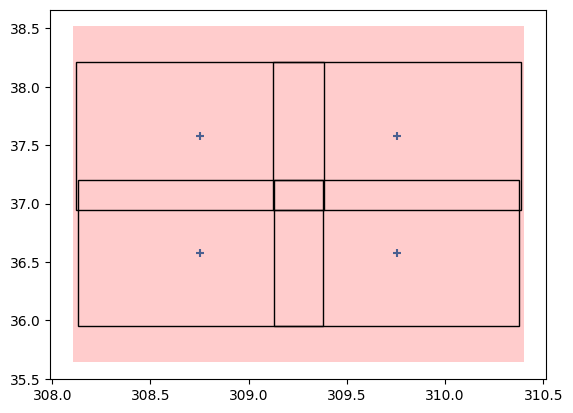

%4|1781147230.204|FAIL|rdkafka#consumer-1| [thrd:sasl_ssl://kafka1.gcn.nasa.gov:9092/1]: sasl_ssl://kafka1.gcn.nasa.gov:9092/1: Disconnected (after 1726361ms in state UP)
%6|1781147230.212|FAIL|rdkafka#consumer-1| [thrd:sasl_ssl://kafka.gcn.nasa.gov:9092/bootstrap]: sasl_ssl://kafka.gcn.nasa.gov:9092/bootstrap: Disconnected (after 1726848ms in state UP)
%6|1781147230.220|FAIL|rdkafka#consumer-1| [thrd:GroupCoordinator]: GroupCoordinator: kafka1.gcn.nasa.gov:9092: Disconnected (after 1726732ms in state UP)


In [35]:
nu.revision = 0
if send_to_winter:
    print("Submitting")
    schedule_winter(nu)
else:
    print("Skipping")

In [ ]:
nu.revision = 1
if send_to_winter:
    print("Submitting")
    schedule_winter(nu)
else:
    print("Skipping")

In [ ]:
get_winter_queue()

In [ ]:
# nu.revision=1